# Silero VAD smoke test on raw recordings

Reads the first few files under `data/raw_audio/` (`.mp3` / `.wav`), prints **container / stream metadata** (channels, native sample rate, codec, PCM subtype or “N/A” for compressed audio), then runs **Silero VAD** on the **customer leg only** when stereo.

For each file, plots are **side by side**: **Before** = full stereo (agent + customer channels overlaid); **After** = customer channel only with **green** bands where Silero marks speech.

**UCall stereo layout:** **left = agent**, **right = customer** → customer = channel index **1** (`CUSTOMER_CHANNEL_INDEX`).

**Why resample to 16 kHz?** Silero VAD is trained for fixed chunk sizes at specific sample rates (for example **512 samples per step at 16 kHz**, about 32 ms). Decoded recordings are often **48 kHz** or another rate; `librosa.load(..., sr=16000)` aligns the signal with what the model expects. Using the wrong rate would break timing and speech detection. Silero also documents an **8 kHz** narrowband mode; that path would use **8000** and the matching model / `sampling_rate` everywhere.

**Step:** Imports, paths, and limits (tune `VAD_TEST_MAX_FILES` here).

In [13]:
from __future__ import annotations

import json
import subprocess
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import soundfile as sf
import torch
from IPython.display import display
from silero_vad import get_speech_timestamps, load_silero_vad

REPO_ROOT = Path.cwd()
RAW_AUDIO_DIR = REPO_ROOT / "data" / "raw_audio"

# How many files (sorted by name) to inspect + run VAD on
VAD_TEST_MAX_FILES = 3

# Silero wideband model: 16 kHz (see intro markdown).
SAMPLING_RATE = 16_000

# UCall stereo: right = customer → 0-based index 1.
CUSTOMER_CHANNEL_INDEX = 1


**Step:** Build a metadata table per file (`ffprobe` for compressed audio; `soundfile` extra fields for WAV).

In [14]:
def ffprobe_audio(path: Path) -> dict:
    """Stream + container fields from ffmpeg (works for mp3, wav, m4a, …)."""
    cmd = [
        "ffprobe",
        "-v",
        "error",
        "-show_entries",
        "stream=codec_name,sample_rate,channels,bits_per_sample",
        "-show_entries",
        "format=duration",
        "-select_streams",
        "a:0",
        "-of",
        "json",
        str(path),
    ]
    raw = subprocess.check_output(cmd, text=True)
    data = json.loads(raw)
    streams = data.get("streams") or [{}]
    st0 = streams[0]
    fmt = data.get("format") or {}
    bps = st0.get("bits_per_sample")
    if bps == 0:
        bps = None  # typical for lossy codecs
    dur = fmt.get("duration")
    return {
        "codec_name": st0.get("codec_name"),
        "sample_rate_hz_probe": int(st0["sample_rate"]) if st0.get("sample_rate") else None,
        "channels_probe": int(st0["channels"]) if st0.get("channels") is not None else None,
        "bits_per_sample": bps,
        "duration_sec_probe": float(dur) if dur is not None else None,
    }


def soundfile_wav_row(path: Path) -> dict | None:
    if path.suffix.lower() != ".wav":
        return None
    info = sf.info(str(path))
    return {
        "wav_subtype": info.subtype,
        "wav_subtype_info": str(info.format),
        "sample_rate_hz_sf": info.samplerate,
        "channels_sf": info.channels,
        "frames_sf": info.frames,
        "duration_sec_sf": info.duration,
    }


def _downsample_1d(y_1d: np.ndarray, sr: int, max_points: int) -> tuple[np.ndarray, np.ndarray]:
    n = len(y_1d)
    if n > max_points:
        idx = np.linspace(0, n - 1, max_points, dtype=int)
        t = idx.astype(np.float64) / sr
        return t, y_1d[idx]
    t = np.arange(n, dtype=np.float64) / sr
    return t, y_1d


def plot_before_full_channels_after_customer_vad(
    y_full: np.ndarray,
    sr: int,
    customer_ch: int,
    stamps: list,
    basename: str,
    *,
    max_points: int = 50_000,
) -> None:
    """Side-by-side: (left) full recording — both channels overlaid; (right) customer channel + green VAD."""
    fig, (ax_before, ax_after) = plt.subplots(
        1,
        2,
        figsize=(14, 3.2),
        sharex=True,
        constrained_layout=True,
    )

    if y_full.ndim == 1:
        n = len(y_full)
        t, y = _downsample_1d(y_full, sr, max_points)
        ax_before.plot(t, y, color="steelblue", linewidth=0.35)
        ax_before.set_title("Before — mono (single channel)")
        customer_wav = y_full
    else:
        n = y_full.shape[1]
        if n > max_points:
            idx = np.linspace(0, n - 1, max_points, dtype=int)
            t = idx.astype(np.float64) / sr
            y0, y1 = y_full[0, idx], y_full[1, idx]
        else:
            t = np.arange(n, dtype=np.float64) / sr
            y0, y1 = y_full[0], y_full[1]
        ax_before.plot(
            t,
            y0,
            color="tab:blue",
            linewidth=0.35,
            label="Ch0 — agent (UCall)",
        )
        ax_before.plot(
            t,
            y1,
            color="tab:orange",
            linewidth=0.35,
            alpha=0.85,
            label="Ch1 — customer (UCall)",
        )
        ax_before.legend(loc="upper right", fontsize=8)
        ax_before.set_title("Before — full stereo (both channels)")
        customer_wav = y_full[min(customer_ch, y_full.shape[0] - 1)]

    ax_before.set_ylabel("Amplitude")
    ax_before.set_xlim(0, n / sr)

    t_c, y_c = _downsample_1d(customer_wav, sr, max_points)
    ax_after.plot(t_c, y_c, color="tab:orange", linewidth=0.35)
    for s in stamps:
        ax_after.axvspan(
            s["start"],
            s["end"],
            alpha=0.32,
            color="tab:green",
            linewidth=0,
        )
    ax_after.set_title("After — customer channel + speech (green)")
    ax_after.set_xlabel("Time (s)")
    ax_before.set_xlabel("Time (s)")

    fig.suptitle(basename, fontsize=11)
    plt.show()


def collect_metadata_rows(paths: list[Path]) -> pl.DataFrame:
    rows: list[dict] = []
    for p in paths:
        row: dict = {"file": p.name}
        try:
            row.update(ffprobe_audio(p))
        except Exception as e:  # noqa: BLE001
            row["probe_error"] = repr(e)
        sf_row = soundfile_wav_row(p)
        if sf_row:
            row.update(sf_row)
        rows.append(row)
    return pl.DataFrame(rows)


audio_files = sorted(RAW_AUDIO_DIR.glob("*.mp3")) + sorted(RAW_AUDIO_DIR.glob("*.wav"))
audio_files = [p for p in audio_files if p.is_file()][:VAD_TEST_MAX_FILES]

if not audio_files:
    print(f"No .mp3/.wav under {RAW_AUDIO_DIR} — run 01_PrepareDataCalls first.")
else:
    meta_df = collect_metadata_rows(audio_files)
    print(f"Metadata ({len(audio_files)} file(s)):")
    # Bare `meta_df` as the last line often produces no cell output in Jupyter/Lab.
    display(meta_df)
    print(meta_df)  # always-visible text table (Polars)


Task was destroyed but it is pending!
task: <Task pending name='Task-178' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/ml-audio-llm/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-179' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/ml-audio-llm/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/ml-audio-llm/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x1072c3c40>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object Kernel.shell_main at 0x1072c3c40>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destroyed but it is pending!
task: <Task pending name='Task-179' coro=<Kernel.shell

Metadata (3 file(s)):


file,codec_name,sample_rate_hz_probe,channels_probe,bits_per_sample,duration_sec_probe
str,str,i64,i64,null,f64
"""014a82d6-4122-498c-a3af-ce9d23…","""mp3""",48000,2,null,9.816
"""0d834264-f791-48c3-8ce7-a12c0a…","""mp3""",48000,2,null,32.328
"""1d08e6b0-976d-493c-9f71-dcef90…","""mp3""",48000,2,null,23.472


shape: (3, 6)
┌─────────────────┬────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ file            ┆ codec_name ┆ sample_rate_hz ┆ channels_probe ┆ bits_per_sampl ┆ duration_sec_p │
│ ---             ┆ ---        ┆ _probe         ┆ ---            ┆ e              ┆ robe           │
│ str             ┆ str        ┆ ---            ┆ i64            ┆ ---            ┆ ---            │
│                 ┆            ┆ i64            ┆                ┆ null           ┆ f64            │
╞═════════════════╪════════════╪════════════════╪════════════════╪════════════════╪════════════════╡
│ 014a82d6-4122-4 ┆ mp3        ┆ 48000          ┆ 2              ┆ null           ┆ 9.816          │
│ 98c-a3af-ce9d23 ┆            ┆                ┆                ┆                ┆                │
│ …               ┆            ┆                ┆                ┆                ┆                │
│ 0d834264-f791-4 ┆ mp3        ┆ 48000          ┆ 2              ┆ null      

**Step:** Load Silero VAD, resample to **`SAMPLING_RATE`** (16 kHz — see intro) with **librosa** (reliable for MP3 here), take **customer channel** when stereo, then `get_speech_timestamps`. Each file gets a **two-panel** figure: full two-channel waveform vs customer track + VAD shading.

---
014a82d6-4122-498c-a3af-ce9d23bb0dba.mp3
stereo (shape (2, 157056)) → ch 1 (customer; agent ch skipped)
segments: 3
first: 1.400s – 1.800s
last:  7.600s – 9.300s


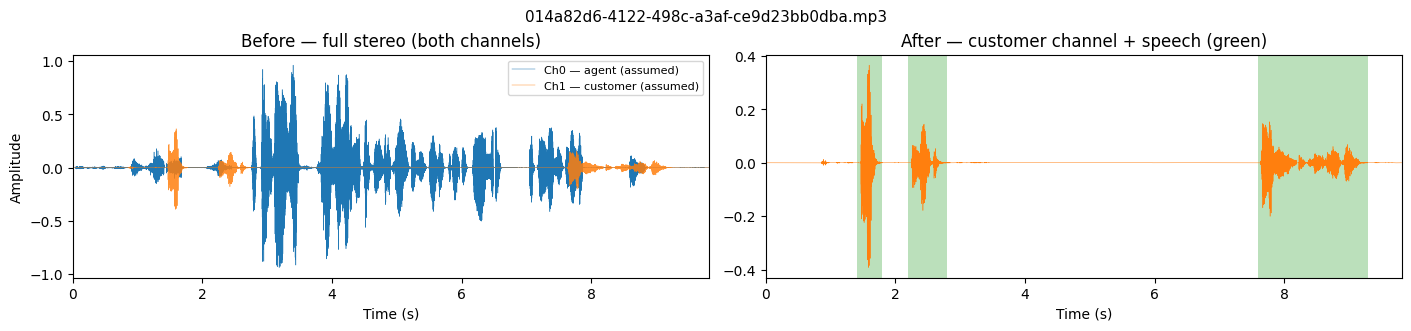

---
0d834264-f791-48c3-8ce7-a12c0a835fe7.mp3
stereo (shape (2, 517248)) → ch 1 (customer; agent ch skipped)
segments: 7
first: 1.900s – 2.400s
last:  27.500s – 28.300s


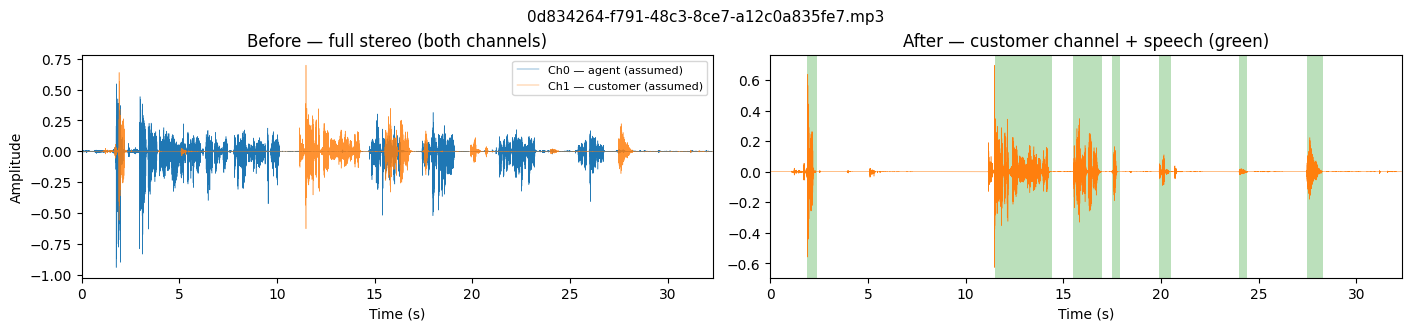

---
1d08e6b0-976d-493c-9f71-dcef90cfd285.mp3
stereo (shape (2, 375552)) → ch 1 (customer; agent ch skipped)
segments: 3
first: 1.100s – 1.500s
last:  19.200s – 21.700s


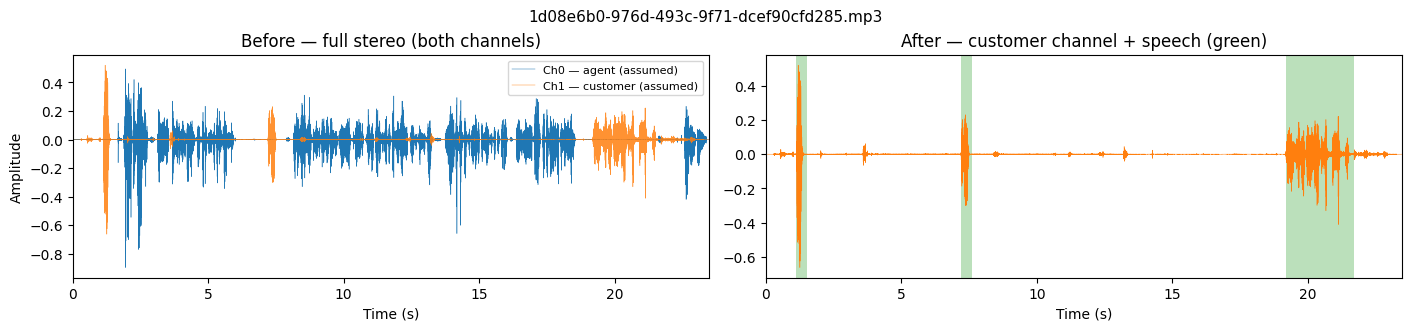

In [15]:
if not audio_files:
    print("Skipping VAD — no input files.")
else:
    torch.set_num_threads(1)
    model = load_silero_vad()

    for path in audio_files:
        y, sr = librosa.load(str(path), sr=SAMPLING_RATE, mono=False)
        if y.ndim == 1:
            wav_np = y
            channel_note = "mono → same stream for VAD"
        else:
            ch = min(CUSTOMER_CHANNEL_INDEX, y.shape[0] - 1)
            wav_np = y[ch]
            channel_note = f"stereo (shape {y.shape}) → ch {ch} (customer; agent ch skipped)"

        wav = torch.from_numpy(wav_np).float()
        stamps = get_speech_timestamps(
            wav,
            model,
            sampling_rate=SAMPLING_RATE,
            return_seconds=True,
        )

        print("---")
        print(path.name)
        print(channel_note)
        print(f"segments: {len(stamps)}")
        if stamps:
            print(f"first: {stamps[0]['start']:.3f}s – {stamps[0]['end']:.3f}s")
            print(f"last:  {stamps[-1]['start']:.3f}s – {stamps[-1]['end']:.3f}s")
        else:
            print("(no speech segments above threshold)")

        plot_before_full_channels_after_customer_vad(
            y,
            SAMPLING_RATE,
            CUSTOMER_CHANNEL_INDEX,
            stamps,
            path.name,
        )
